# Hamiltonian Flow Matching - Smooth Coulomb Roots Rotated Bridge

This notebook transports an even number of labeled particles on the roots of unity.  Each particle starts
near one root on a circle of radius `R` and is transported to the same circle rotated by `theta`.  All particles interact
through a smoothed pairwise Coulomb potential, so the learned configuration is
`q = (q1_x, q1_y, ..., qN_x, qN_y)`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import math
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import (
    MeanStdBVPGaussianPath, flow_matching_loss,
    SmoothCoulombPotential,
    to_numpy, as_particles as _as_particles, make_hamiltonian_node, make_mean_std_bvp_path,
    solve_bvp_paths, train_on_cached_path_pairs, train_on_ot_pairs as _train_on_ot_pairs,
    simulate_model_trajectory, cached_mean_trajectory, trajectory_hamiltonian,
)
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.models.models_v2 import MLP
from torchcfm.utils import torch_wrapper

if torch.cuda.is_available() and torch.cuda.device_count() > 2:
    device = torch.device('cuda:3')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')


In [12]:
torch.manual_seed(42)
np.random.seed(42)

# Even number of labeled Coulomb particles in 2D.
n_particles = 6
if n_particles % 2 != 0:
    raise ValueError('n_particles must be even for this example.')

particle_dim = 2
dim = n_particles * particle_dim

# Endpoint geometry: N roots of unity on a radius-R circle.
R = 2.0
angles = 2.0 * math.pi * torch.arange(n_particles, device=device, dtype=torch.get_default_dtype()) / n_particles
source_positions = R * torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)

# Terminal means are the source roots rotated counterclockwise by theta.
theta = math.pi / 3.0
rotation_matrix = torch.tensor(
    [
        [math.cos(theta), -math.sin(theta)],
        [math.sin(theta), math.cos(theta)],
    ],
    device=device,
    dtype=source_positions.dtype,
)
target_positions = source_positions @ rotation_matrix.T
source_mean = source_positions.reshape(-1)
target_mean = target_positions.reshape(-1)

# Endpoint distributions.
endpoint_std = 0.1

# Coulomb constants.  Like charges are repulsive under x'' = -grad V.
coulomb_constant = 2.0
softening_epsilon = 0.1
charges = torch.ones(n_particles, device=device, dtype=source_positions.dtype)
# charges[0] =  -3.0

# Training controls. Increase n_dataset/n_epochs/n_iters for production runs.
batch_size = 128
n_dataset = 128
n_epochs = 5
n_iters = 1000
n_warmup_iters = 5000
batch_size_warmup = 1024
lr = 5e-4
bvp_sigma = 0.001
n_steps = 40
tol = 1e-2
quadrature_order  = 3
eval_batch = 100
solve_t_span = torch.linspace(0, 1, n_steps + 1, device=device)

print(f'device: {device}')
print(f'n_particles: {n_particles}, dim: {dim}')
print(f'R: {R}, theta: {theta:.4f} rad, endpoint_std: {endpoint_std}')
print(f'source means:\n{source_positions}')
print(f'target means:\n{target_positions}')

device: cuda:3
n_particles: 6, dim: 12
R: 2.0, theta: 1.0472 rad, endpoint_std: 0.1
source means:
tensor([[ 2.0000e+00,  0.0000e+00],
        [ 1.0000e+00,  1.7321e+00],
        [-1.0000e+00,  1.7321e+00],
        [-2.0000e+00, -1.7485e-07],
        [-1.0000e+00, -1.7321e+00],
        [ 1.0000e+00, -1.7321e+00]], device='cuda:3')
target means:
tensor([[ 1.0000e+00,  1.7321e+00],
        [-1.0000e+00,  1.7321e+00],
        [-2.0000e+00, -1.1921e-07],
        [-1.0000e+00, -1.7321e+00],
        [ 1.0000e+00, -1.7321e+00],
        [ 2.0000e+00,  7.1526e-07]], device='cuda:3')


## Smoothed Pairwise Coulomb Potential

The notebook-local potential is

$$
V(q) = k \sum_{i<j} \frac{c_i c_j}{\sqrt{\|q_i-q_j\|^2 + \epsilon^2}}.
$$

The smoothing parameter `softening_epsilon` prevents division by zero when two particles get close.

In [13]:
potential = SmoothCoulombPotential(
    n_particles=n_particles,
    charges=charges,
    coulomb_constant=coulomb_constant,
    epsilon=softening_epsilon,
)

q_test = source_mean.reshape(1, -1)
print(f"V(source_mean) = {potential.energy(q_test).item():.6f}")
print(f"force(source_mean) = {potential.force(q_test).reshape(n_particles, particle_dim)}")

V(source_mean) = 10.954703
force(source_mean) = tensor([[ 9.1133e-01,  4.1723e-07],
        [ 4.5566e-01,  7.8923e-01],
        [-4.5566e-01,  7.8923e-01],
        [-9.1133e-01, -1.1921e-07],
        [-4.5566e-01, -7.8923e-01],
        [ 4.5566e-01, -7.8923e-01]], device='cuda:3')


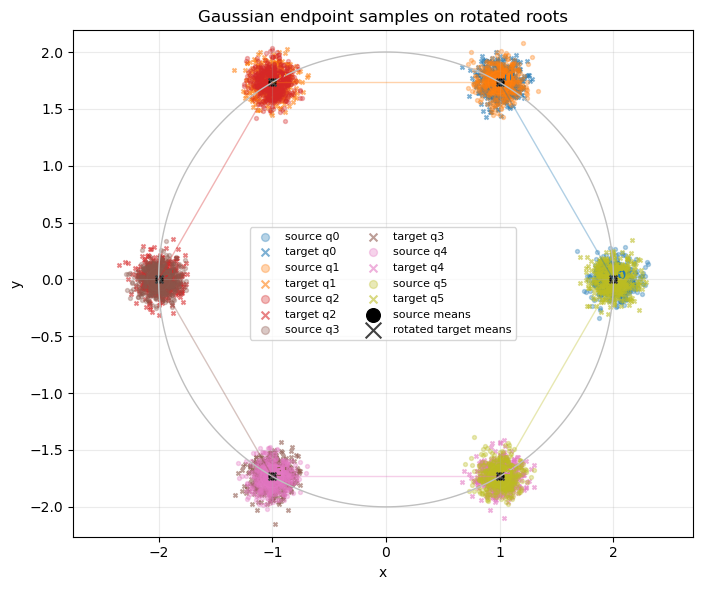

In [14]:
source_dist = torch.distributions.Normal(source_mean, endpoint_std)
target_dist = torch.distributions.Normal(target_mean, endpoint_std)


def sample_source(n):
    return source_dist.sample((n,)).to(device)


def sample_target(n):
    return target_dist.sample((n,)).to(device)


def as_particles(q):
    return _as_particles(q, n_particles, particle_dim)


def particle_colors():
    cmap = plt.cm.hsv if n_particles > 10 else plt.cm.tab10
    return cmap(np.linspace(0, 1, n_particles, endpoint=False))


def maybe_label(text, idx):
    return text if n_particles <= 12 else None


def plot_endpoint_samples(x0, x1, title, n_show=500):
    n_show = min(n_show, x0.shape[0], x1.shape[0])
    x0p = to_numpy(as_particles(x0[:n_show]))
    x1p = to_numpy(as_particles(x1[:n_show]))
    src = to_numpy(source_positions)
    tgt = to_numpy(target_positions)
    colors = particle_colors()

    circle_theta = np.linspace(0, 2 * np.pi, 256)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(R * np.cos(circle_theta), R * np.sin(circle_theta), color='0.75', linewidth=1.0)

    for i, color in enumerate(colors):
        ax.scatter(x0p[:, i, 0], x0p[:, i, 1], s=8, color=color, alpha=0.32, label=maybe_label(f'source q{i}', i))
        ax.scatter(x1p[:, i, 0], x1p[:, i, 1], s=8, color=color, marker='x', alpha=0.58, label=maybe_label(f'target q{i}', i))
        ax.add_patch(plt.Circle((src[i, 0], src[i, 1]), endpoint_std, fill=False, color=color, alpha=0.8, linewidth=1.1))
        ax.add_patch(plt.Circle((tgt[i, 0], tgt[i, 1]), endpoint_std, fill=False, color=color, alpha=0.8, linewidth=1.1, linestyle='--'))
        ax.plot([src[i, 0], tgt[i, 0]], [src[i, 1], tgt[i, 1]], color=color, alpha=0.35, linewidth=1.0)
        ax.text(src[i, 0], src[i, 1], f' {i}', color=color, fontsize=9, weight='bold')
        ax.text(tgt[i, 0], tgt[i, 1], f' {i}\'', color=color, fontsize=9)

    ax.scatter(src[:, 0], src[:, 1], color='black', s=24, label='source means')
    ax.scatter(tgt[:, 0], tgt[:, 1], color='0.25', marker='x', s=32, label='rotated target means')
    ax.axis('equal')
    ax.grid(alpha=0.25)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(title)
    ax.legend(markerscale=2, fontsize=8, ncols=2)
    plt.tight_layout()
    plt.show()


x0_vis = sample_source(500)
x1_vis = sample_target(500)
plot_endpoint_samples(x0_vis, x1_vis, 'Gaussian endpoint samples on rotated roots')

## BVP Path, Models, and Training Helpers

The nonlinear reference paths are solved with `MeanStdBVPGaussianPath`.  The alternating training loop
reuses couplings induced by the current opposite-direction NODE.

In [15]:
ot_sampler = OTPlanSampler(method='exact')

fwd_model = MLP(dim, out_dim=dim, w=256, time_varying=True).to(device)
bwd_model = MLP(dim, out_dim=dim, w=256, time_varying=True).to(device)
fwd_optimizer = torch.optim.Adam(fwd_model.parameters(), lr=lr)
bwd_optimizer = torch.optim.Adam(bwd_model.parameters(), lr=lr)

fwd_losses = []
bwd_losses = []


def make_node(model):
    return make_hamiltonian_node(model)


def make_path():
    return make_mean_std_bvp_path(
        potential,
        sigma=bvp_sigma,
        n_steps=n_steps,
        tol=tol,
        quadrature_order=quadrature_order,
        use_monte_carlo=True,
    )


def solve_paths(x0, x1, label="path"):
    return solve_bvp_paths(make_path, x0, x1, label=label, description="smooth Coulomb BVPs")


def train_on_cached_paths(model, optimizer, path, x0, x1, n_steps_train, label, log_every=200):
    return train_on_cached_path_pairs(
        model, optimizer, path, x0, x1, n_steps_train, label,
        batch_size=batch_size,
        device=device,
        log_every=log_every,
        no_pairs_message="no successful BVP pairs to train on",
    )


def train_on_ot_pairs(model, optimizer, x0, x1, n_steps_train, label, log_every=500):
    return _train_on_ot_pairs(
        model, optimizer, x0, x1, n_steps_train, label,
        batch_size=batch_size,
        device=device,
        log_every=log_every,
    )

## Initial BVP Dataset

Solving 128 initial smooth Coulomb BVPs...
initial: kept 127 / 128 BVPs; failed 1; states: torch.Size([127, 41, 26])
initial: first failures: [(0, 'The maximum number of mesh nodes is exceeded.')]


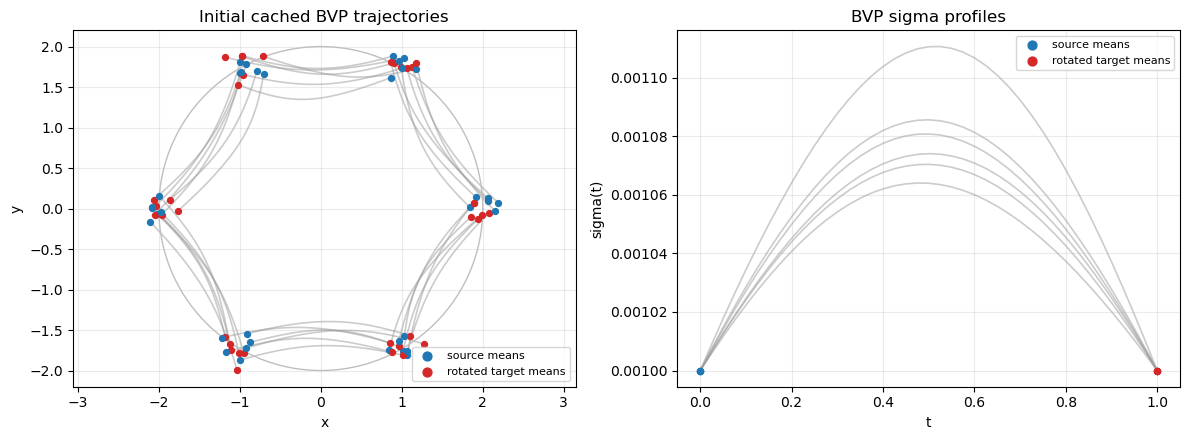

In [16]:
x0_all = sample_source(n_dataset)
x1_all = sample_target(n_dataset)
x0_coupled, x1_coupled = ot_sampler.sample_plan(x0_all, x1_all)
path, x0_coupled, x1_coupled, states = solve_paths(x0_coupled, x1_coupled, label='initial')
n_dataset = x0_coupled.shape[0]

plot_idx = np.linspace(0, n_dataset - 1, min(6, n_dataset)).astype(int)
t_state = to_numpy(path.t_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for plot_pos, idx in enumerate(plot_idx):
    mu = to_numpy(as_particles(states[idx, :, :dim]))   # (n_time, n_particles, 2)
    sigma = to_numpy(states[idx, :, 2 * dim])           # (n_time,) scalar std per time

    # Label blue=source / red=target once so the legend stays clean.
    src_label = 'source means' if plot_pos == 0 else None
    tgt_label = 'rotated target means' if plot_pos == 0 else None

    # Left panel: mean trajectory of each particle, source endpoint (t=0) blue, target (t=1) red.
    for pidx in range(n_particles):
        axes[0].plot(mu[:, pidx, 0], mu[:, pidx, 1], color='0.6', linewidth=1.2, alpha=0.5)
        axes[0].scatter(mu[0, pidx, 0], mu[0, pidx, 1], color='tab:blue', s=18, zorder=3,
                        label=src_label if pidx == 0 else None)
        axes[0].scatter(mu[-1, pidx, 0], mu[-1, pidx, 1], color='tab:red', s=18, zorder=3,
                        label=tgt_label if pidx == 0 else None)

    # Right panel: sigma(t), source end blue, target end red.
    axes[1].plot(t_state, sigma, color='0.6', linewidth=1.2, alpha=0.5)
    axes[1].scatter(t_state[0], sigma[0], color='tab:blue', s=18, zorder=3, label=src_label)
    axes[1].scatter(t_state[-1], sigma[-1], color='tab:red', s=18, zorder=3, label=tgt_label)

circle_theta = np.linspace(0, 2 * np.pi, 256)
axes[0].plot(R * np.cos(circle_theta), R * np.sin(circle_theta), color='0.75', linewidth=1.0)
axes[0].axis('equal')
axes[0].grid(alpha=0.25)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Initial cached BVP trajectories')
axes[0].legend(markerscale=1.5, fontsize=8)
axes[1].set_xlabel('t')
axes[1].set_ylabel('sigma(t)')
axes[1].set_title('BVP sigma profiles')
axes[1].grid(alpha=0.25)
axes[1].legend(markerscale=1.5, fontsize=8)
plt.tight_layout()
plt.show()

## Warm Start on Straight OT Pairs

In [60]:
warm_x0 = sample_source(batch_size_warmup)
warm_x1 = sample_target(batch_size_warmup)
warm_x0, warm_x1 = ot_sampler.sample_plan(warm_x0, warm_x1)

print('Warm-start forward model on straight OT pairs...')
fwd_losses.extend(train_on_ot_pairs(fwd_model, fwd_optimizer, warm_x0, warm_x1, n_warmup_iters, 'fwd warm'))
print('Warm-start backward model on straight OT pairs...')
bwd_losses.extend(train_on_ot_pairs(bwd_model, bwd_optimizer, warm_x1, warm_x0, n_warmup_iters, 'bwd warm'))

Warm-start forward model on straight OT pairs...
fwd warm step     0: loss = 2.22371
fwd warm step   500: loss = 0.00540
fwd warm step  1000: loss = 0.00478
fwd warm step  1500: loss = 0.00499
fwd warm step  2000: loss = 0.00497
fwd warm step  2500: loss = 0.00500
fwd warm step  3000: loss = 0.00475
fwd warm step  3500: loss = 0.00512
fwd warm step  4000: loss = 0.00489
fwd warm step  4500: loss = 0.00509
fwd warm step  4999: loss = 0.00539
Warm-start backward model on straight OT pairs...
bwd warm step     0: loss = 1.90052
bwd warm step   500: loss = 0.00506
bwd warm step  1000: loss = 0.00542
bwd warm step  1500: loss = 0.00541
bwd warm step  2000: loss = 0.00485
bwd warm step  2500: loss = 0.00499
bwd warm step  3000: loss = 0.00525
bwd warm step  3500: loss = 0.00491
bwd warm step  4000: loss = 0.00525
bwd warm step  4500: loss = 0.00532
bwd warm step  4999: loss = 0.00464


## Alternating Forward/Backward Training

In [61]:
last_fwd_path = None
last_bwd_path = None
last_fwd_states = None
last_bwd_states = None
last_fwd_x0, last_fwd_x1 = None, None
last_bwd_x0, last_bwd_x1 = None, None

for epoch in range(n_epochs):
    print(f'\n=== Alternating epoch {epoch + 1} / {n_epochs} ===')

    if epoch % 2 == 0:
        # Train fwd using couplings induced by the current bwd NODE.
        y_target = sample_target(n_dataset)
        bwd_model.eval()
        bwd_node = make_node(bwd_model)
        with torch.no_grad():
            bwd_traj = bwd_node.trajectory(y_target, t_span=solve_t_span)
        generated_source = bwd_traj[-1].detach()

        last_fwd_path, last_fwd_x0, last_fwd_x1, last_fwd_states = solve_paths(
            generated_source,
            y_target,
            label=f'epoch {epoch} fwd',
        )
        fwd_losses.extend(
            train_on_cached_paths(
                fwd_model,
                fwd_optimizer,
                last_fwd_path,
                last_fwd_x0,
                last_fwd_x1,
                n_iters,
                label=f'epoch {epoch} fwd',
            )
        )
    else:
        # Train bwd using couplings induced by the current fwd NODE.
        x_source = sample_source(n_dataset)
        fwd_model.eval()
        fwd_node = make_node(fwd_model)
        with torch.no_grad():
            fwd_traj = fwd_node.trajectory(x_source, t_span=solve_t_span)
        generated_target = fwd_traj[-1].detach()

        last_bwd_path, last_bwd_x0, last_bwd_x1, last_bwd_states = solve_paths(
            generated_target,
            x_source,
            label=f'epoch {epoch} bwd',
        )
        bwd_losses.extend(
            train_on_cached_paths(
                bwd_model,
                bwd_optimizer,
                last_bwd_path,
                last_bwd_x0,
                last_bwd_x1,
                n_iters,
                label=f'epoch {epoch} bwd',
            )
        )


=== Alternating epoch 1 / 5 ===
Solving 32 epoch 0 fwd smooth Coulomb BVPs...
epoch 0 fwd: kept 31 / 32 BVPs; failed 1; states: torch.Size([31, 41, 26])
epoch 0 fwd: first failures: [(28, 'The maximum number of mesh nodes is exceeded.')]
epoch 0 fwd step     0: loss = 0.07728
epoch 0 fwd step   200: loss = 0.00253
epoch 0 fwd step   400: loss = 0.00110
epoch 0 fwd step   600: loss = 0.00065
epoch 0 fwd step   800: loss = 0.00046
epoch 0 fwd step   999: loss = 0.00050

=== Alternating epoch 2 / 5 ===
Solving 32 epoch 1 bwd smooth Coulomb BVPs...
epoch 1 bwd: kept 30 / 32 BVPs; failed 2; states: torch.Size([30, 41, 26])
epoch 1 bwd: first failures: [(1, 'The maximum number of mesh nodes is exceeded.'), (16, 'The maximum number of mesh nodes is exceeded.')]
epoch 1 bwd step     0: loss = 0.07941
epoch 1 bwd step   200: loss = 0.00175
epoch 1 bwd step   400: loss = 0.00079
epoch 1 bwd step   600: loss = 0.00051
epoch 1 bwd step   800: loss = 0.00029
epoch 1 bwd step   999: loss = 0.00030


## Training Losses

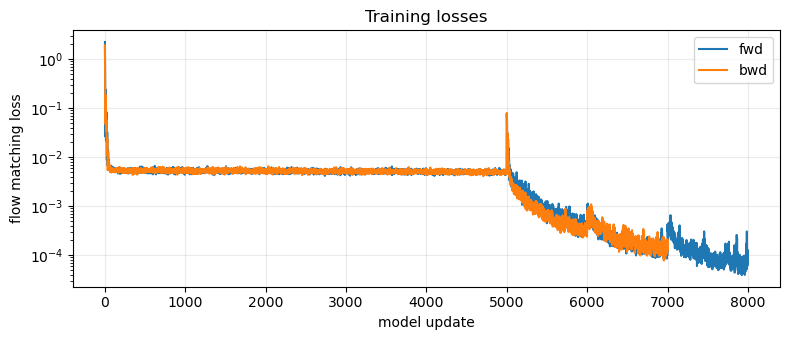

In [66]:
plt.figure(figsize=(8, 3.5))
plt.semilogy(fwd_losses, label='fwd')
plt.semilogy(bwd_losses, label='bwd')
plt.xlabel('model update')
plt.ylabel('flow matching loss')
plt.title('Training losses')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## Learned Flow Evaluation

In [67]:
def simulate_model(model, x0, t_span):
    node = make_node(model)
    model.eval()
    with torch.no_grad():
        traj = node.trajectory(x0.to(device), t_span.to(device))
    return traj


eval_t_span = torch.linspace(0, 1, 101, device=device)
x0_eval = sample_source(eval_batch*50)
x1_eval = sample_target(eval_batch*50)

fwd_traj = simulate_model(fwd_model, x0_eval, eval_t_span)
bwd_traj = simulate_model(bwd_model, x1_eval, eval_t_span)


def print_gaussian_summary(label, traj, reference_mean):
    terminal = traj[-1]
    generated_mean = terminal.mean(dim=0)
    generated_std = terminal.std(dim=0, unbiased=True).mean().item()
    mean_rmse = (generated_mean - reference_mean).pow(2).mean().sqrt().item()
    print(f'{label} terminal mean RMSE: {mean_rmse:.4f}')
    print(f'{label} average coordinate std: {generated_std:.4f} (target {endpoint_std:.4f})')


print_gaussian_summary('Forward', fwd_traj, target_mean)
print_gaussian_summary('Backward', bwd_traj, source_mean)

Forward terminal mean RMSE: 0.0345
Forward average coordinate std: 0.1037 (target 0.1000)
Backward terminal mean RMSE: 0.0314
Backward average coordinate std: 0.1024 (target 0.1000)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


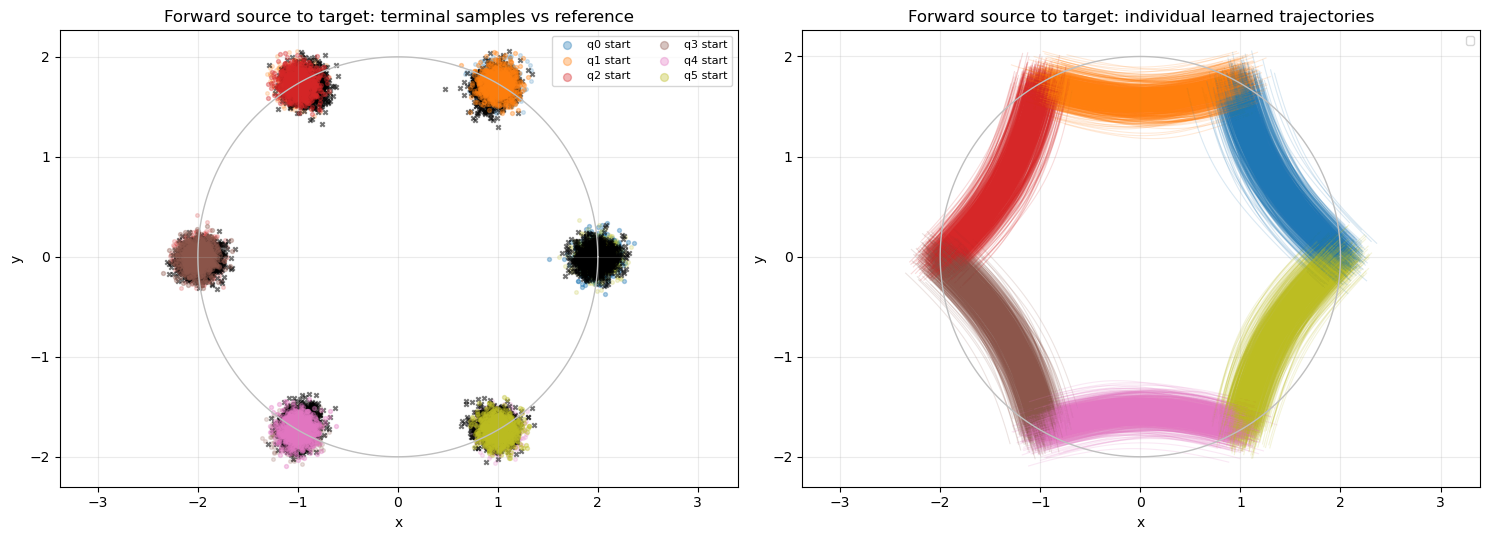

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


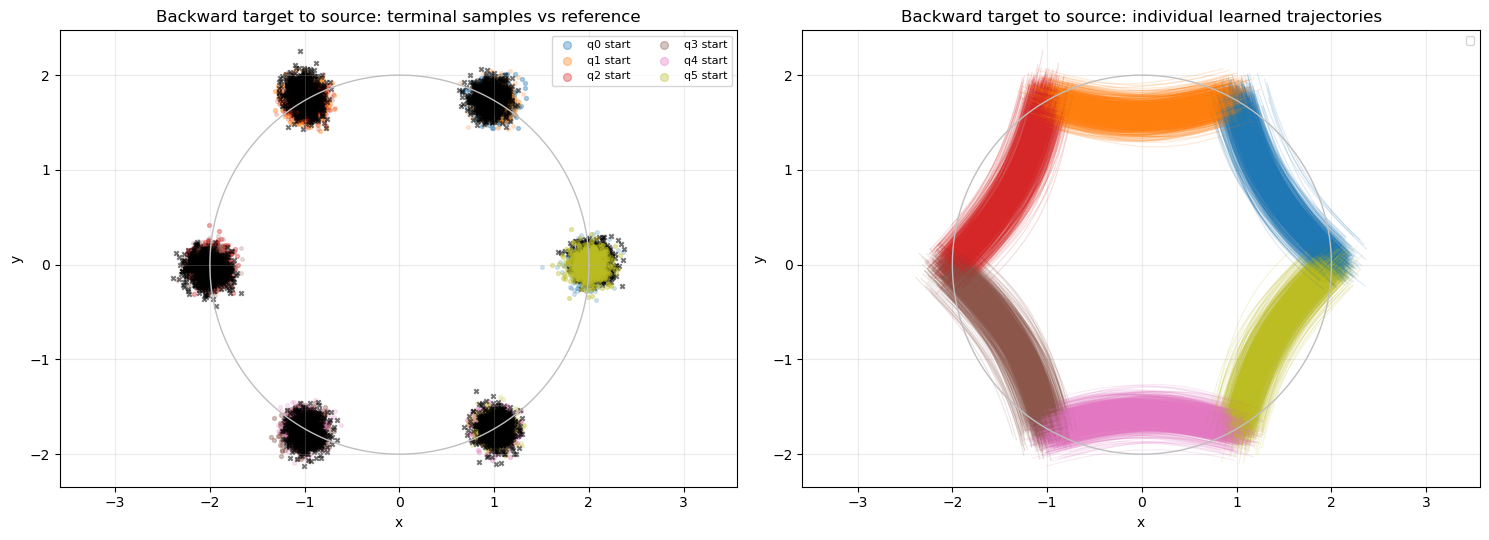

In [69]:
def plot_learned_coulomb_trajectories(traj, reference, title, n_show=500, n_lines=100):
    n_show = min(n_show, traj.shape[1], reference.shape[0])
    n_lines = min(n_lines, traj.shape[1])
    traj_particles = to_numpy(as_particles(traj.detach().cpu()))
    ref_particles = to_numpy(as_particles(reference.detach().cpu()))
    colors = particle_colors()
    circle_theta = np.linspace(0, 2 * np.pi, 256)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    for pidx, color in enumerate(colors):
        axes[0].scatter(traj_particles[0, :n_show, pidx, 0], traj_particles[0, :n_show, pidx, 1], s=8, color=color, alpha=0.35, label=maybe_label(f'q{pidx} start', pidx))
        axes[0].scatter(ref_particles[:n_show, pidx, 0], ref_particles[:n_show, pidx, 1], s=7, color=color, alpha=0.18)
        axes[0].scatter(traj_particles[-1, :n_show, pidx, 0], traj_particles[-1, :n_show, pidx, 1], s=10, color='black', marker='x', alpha=0.55)
    axes[0].set_title(f'{title}: terminal samples vs reference')

    for i in range(n_lines):
        for pidx, color in enumerate(colors):
            axes[1].plot(traj_particles[:, i, pidx, 0], traj_particles[:, i, pidx, 1], color=color, alpha=0.16, linewidth=0.8)
    axes[1].set_title(f'{title}: individual learned trajectories')

    for ax in axes:
        ax.plot(R * np.cos(circle_theta), R * np.sin(circle_theta), color='0.75', linewidth=1.0)
        ax.axis('equal')
        ax.grid(alpha=0.25)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        if n_particles <= 12:
            ax.legend(markerscale=2, fontsize=8, ncols=2)

    plt.tight_layout()
    plt.show()


plot_learned_coulomb_trajectories(fwd_traj, x1_eval, 'Forward source to target',n_show =eval_batch*10, n_lines = eval_batch*10)
plot_learned_coulomb_trajectories(bwd_traj, x0_eval, 'Backward target to source',n_show =eval_batch*10, n_lines = eval_batch*10)

## Forward NODE vs Direct Coulomb BVP

In [65]:
comparison_batch = min(eval_batch, fwd_traj.shape[1])
learned_traj = fwd_traj[:, :comparison_batch]
x0_cmp = x0_eval[:comparison_batch]
generated_target = learned_traj[-1].detach()

cmp_path = make_path()
cmp_path.batch_solve(x0_cmp, generated_target)
keep = cmp_path.success_mask.to(device=device)
x0_cmp_keep = x0_cmp[keep]
generated_target_keep = generated_target[keep]
learned_traj_keep = learned_traj[:, keep]
if x0_cmp_keep.shape[0] == 0:
    raise RuntimeError('No successful comparison BVPs.')
closed_form_traj = cached_mean_trajectory(cmp_path, x0_cmp_keep, generated_target_keep, eval_t_span)

per_time_rmse = (learned_traj_keep - closed_form_traj).pow(2).mean(dim=(1, 2)).sqrt()
trajectory_rmse = per_time_rmse.pow(2).mean().sqrt().item()
print(f'Forward NODE vs direct Coulomb BVP trajectory RMSE: {trajectory_rmse:.6e}')
print(f'Comparison BVPs kept: {x0_cmp_keep.shape[0]} / {comparison_batch}')

n_compare_lines = min(100, x0_cmp_keep.shape[0])
learned_particles = to_numpy(as_particles(learned_traj_keep[:, :n_compare_lines]))
closed_particles = to_numpy(as_particles(closed_form_traj[:, :n_compare_lines]))
time_rmse = to_numpy(per_time_rmse)
t_eval_plot = to_numpy(eval_t_span)
colors = particle_colors()
circle_theta = np.linspace(0, 2 * np.pi, 256)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for i in range(n_compare_lines):
    for pidx, color in enumerate(colors):
        axes[0].plot(learned_particles[:, i, pidx, 0], learned_particles[:, i, pidx, 1], color=color, alpha=0.14, linewidth=0.8)
        axes[1].plot(closed_particles[:, i, pidx, 0], closed_particles[:, i, pidx, 1], color=color, alpha=0.14, linewidth=0.8)

for pidx, color in enumerate(colors):
    axes[0].scatter(learned_particles[0, :, pidx, 0], learned_particles[0, :, pidx, 1], s=7, color=color, alpha=0.55)
    axes[0].scatter(learned_particles[-1, :, pidx, 0], learned_particles[-1, :, pidx, 1], s=9, color='black', marker='x', alpha=0.65)
    axes[1].scatter(closed_particles[0, :, pidx, 0], closed_particles[0, :, pidx, 1], s=7, color=color, alpha=0.55)
    axes[1].scatter(closed_particles[-1, :, pidx, 0], closed_particles[-1, :, pidx, 1], s=9, color='black', marker='x', alpha=0.65)

axes[0].set_title('Learned forward NODE trajectories')
axes[1].set_title('Direct smooth Coulomb BVP trajectories')
axes[2].plot(t_eval_plot, time_rmse, color='black', linewidth=2.0)
axes[2].set_xlabel('t')
axes[2].set_ylabel('RMSE')
axes[2].set_title('Per-time trajectory RMSE')
axes[2].grid(alpha=0.25)

for ax in axes[:2]:
    ax.plot(R * np.cos(circle_theta), R * np.sin(circle_theta), color='0.75', linewidth=1.0)
    ax.axis('equal')
    ax.grid(alpha=0.25)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## Hamiltonian Diagnostics

In [13]:
H = trajectory_hamiltonian(fwd_traj[:, :diagnostic_batch], eval_t_span, potential)
H_np = to_numpy(H)

plt.figure(figsize=(8, 4))
plt.plot(to_numpy(eval_t_span), H_np[:, : min(30, diagnostic_batch)], color='0.25', alpha=0.22, linewidth=0.8)
plt.plot(to_numpy(eval_t_span), H_np.mean(axis=1), color='black', linewidth=2.0, label='mean')
plt.xlabel('t')
plt.ylabel('H(t)')
plt.title('Approximate Hamiltonian along learned forward trajectories')
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'diagnostic_batch' is not defined